# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Htet Htet Win



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [1]:
## Data handling
import pandas as pd
import numpy as np

## Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix , ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# 1. Business Understanding

Sleep is an important part of a person’s health and daily life. However, some people may not realise that their lifestyle habits or health readings could be linked to a sleep disorder. Problems such as Insomnia and Sleep Apnea can affect a person’s energy, concentration, mood and overall well-being.

The goal of this project is to develop a machine learning model that can predict a person’s possible sleep-disorder category using their health and lifestyle information. The model will consider features such as sleep duration, quality of sleep, stress level, physical activity, BMI category, blood pressure, heart rate and daily steps.

This is a **classification problem** because the model predicts a category instead of a continuous numerical value. The target column is **`Sleep Disorder`**, which contains three possible classes:

* No Sleep Disorder
* Insomnia
* Sleep Apnea

The solution is mainly intended for people who want to understand their possible sleep-disorder risk. It may also be useful as an early screening tool for wellness programmes. Through the Streamlit web application, users can enter their information and receive an immediate prediction in a simple and understandable format.

The model will be evaluated using **accuracy and Macro F1-score**. Accuracy shows the overall percentage of correct predictions. Macro F1 is also important because it gives equal importance to all three classes. This prevents a larger class from hiding poor performance for Insomnia or Sleep Apnea.

This solution is designed to provide early awareness and should not be treated as a medical diagnosis. Predictions may not always be correct because the model is trained using a limited dataset. Users who are concerned about their sleep or health should still consult a qualified healthcare professional.


# 2. Data Understanding

## 2.1 Load Dataset

The Sleep Health and Lifestyle Dataset is used for this project. It contains information about a person's sleep, lifestyle and health. The target column is `Sleep Disorder`.

Dataset source: https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset


In [2]:
# File and worksheet used for this project
DATA_FILE = "Sleep_Health_and_Lifestyle_Dataset.xlsx"
SHEET_NAME = "Sleep_Health_and_Lifestyle_Data"

# Load the dataset into a pandas DataFrame
df = pd.read_excel(DATA_FILE, sheet_name=SHEET_NAME)

print("Dataset loaded successfully.")

# Display the first five rows to check the dataset
display(df.head())

# Display the dataset size clearly
rows, columns = df.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {columns}")

Dataset loaded successfully.


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Systolic BP,Diastolic BP,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126,83,77,4200,No Sleep Disorder
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125,80,75,10000,No Sleep Disorder
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125,80,75,10000,No Sleep Disorder
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140,90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140,90,85,3000,Sleep Apnea


Number of rows: 374
Number of columns: 14


The dataset was loaded successfully and contains 374 rows and 14 columns. Each row represents one person, while the columns contain their sleep, lifestyle and health information. The first five rows were displayed to confirm that the dataset was loaded correctly.

## 2.2 Summary Statistics

This section checks the dataset structure, data types, missing values, duplicate rows and basic distributions. This helps identify problems that may need to be handled before training the models.

### 2.2.1 Dataset Structure and Data Types

In [3]:
# Display the dataset structure and data type of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Systolic BP              374 non-null    int64  
 10  Diastolic BP             374 non-null    int64  
 11  Heart Rate               374 non-null    int64  
 12  Daily Steps              374 non-null    int64  
 13  Sleep Disorder           374 non-null    object 
dtypes: float64(1), int64(9), o

The dataset contains both numerical and categorical columns. Checking the data types is important because numerical and categorical features require different preparation before they can be used for model training.

### 2.2.2 Missing Values

In [4]:
# Calculate the number and percentage of missing values
missing_summary = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing Percentage (%)": (df.isna().mean() * 100).round(2)
})

# Display columns with the highest missing values first
missing_summary = missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

display(missing_summary)

,Missing Values,Missing Percentage (%)
Person ID,0,0.0
Gender,0,0.0
Age,0,0.0
Occupation,0,0.0
Sleep Duration,0,0.0
Quality of Sleep,0,0.0
Physical Activity Level,0,0.0
Stress Level,0,0.0
BMI Category,0,0.0
Systolic BP,0,0.0


### 2.2.3 Duplicated Rows

In [5]:
# Check whether the dataset contains duplicate rows
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


No duplicate rows were found in the dataset.

Duplicate rows were checked because repeated records could affect the model and make some patterns appear more common than they really are.

### 2.2.4 Numerical Summary

In [6]:
# Display summary statistics for numerical columns
numerical_summary = df.describe().T.round(2)

display(numerical_summary)

,count,mean,std,min,25%,50%,75%,max
Person ID,374.0,187.50,108.11,1.0,94.25,187.5,280.75,374.0
Age,374.0,42.18,8.67,27.0,35.25,43.0,50.00,59.0
Sleep Duration,374.0,7.13,0.80,5.8,6.40,7.2,7.80,8.5
Quality of Sleep,374.0,7.31,1.20,4.0,6.00,7.0,8.00,9.0
Physical Activity Level,374.0,59.17,20.83,30.0,45.00,60.0,75.00,90.0
Stress Level,374.0,5.39,1.77,3.0,4.00,5.0,7.00,8.0
Systolic BP,374.0,128.55,7.75,115.0,125.00,130.0,135.00,142.0
Diastolic BP,374.0,84.65,6.16,75.0,80.00,85.0,90.00,95.0
Heart Rate,374.0,70.17,4.14,65.0,68.00,70.0,72.00,86.0
Daily Steps,374.0,6816.84,1617.92,3000.0,5600.00,7000.0,8000.00,10000.0


The numerical summary shows the average, minimum, maximum and spread of each numerical feature. These results help identify unusual values and features with different measurement ranges.

### 2.2.5 Categorical Summary

In [7]:
# Display summary statistics for categorical columns
categorical_summary = df.describe(include="object").T

display(categorical_summary)

,count,unique,top,freq
Gender,374,2,Male,189
Occupation,374,11,Nurse,73
BMI Category,374,4,Normal,195
Sleep Disorder,374,3,No Sleep Disorder,219


The categorical summary shows the number of unique values and the most common value in each categorical column. This helps identify category inconsistencies and features that will require encoding.

### 2.2.6 Target Distribution

In [8]:
# Check the number and percentage of records in each target class
target_counts = df["Sleep Disorder"].value_counts(dropna=False)
target_percentages = (
    df["Sleep Disorder"]
    .value_counts(dropna=False, normalize=True)
    .mul(100)
    .round(2)
)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage (%)": target_percentages
})

display(target_summary)

,Count,Percentage (%)
Sleep Disorder,,
No Sleep Disorder,219,58.56
Sleep Apnea,78,20.86
Insomnia,77,20.59


The target distribution was checked to understand how many records belong to each sleep-disorder class. This is important because a large difference between the class sizes could affect model training and make accuracy alone misleading.

### Summary of Findings

The dataset contains 374 rows and 14 columns. It includes both numerical and categorical variables. `Person ID` is an identifier column and is not used for modelling.

The dataset has no missing values across any of the columns. This indicates that all records are complete.

No duplicate rows were found in the dataset, meaning each entry represents a unique individual.

The numerical summary shows variation across features such as age, sleep duration, and physical activity level. These variables have different scales and ranges, which will need to be considered during modelling.

The categorical summary shows that variables such as gender, occupation, and BMI category contain multiple distinct groups. These features will need to be encoded before they can be used in machine learning models.

The target variable `Sleep Disorder` shows an uneven distribution across its classes, with one class appearing more frequently than the others.


## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Distribution of Target

The distribution of `Sleep Disorder` is visualised to check whether the target classes are balanced.

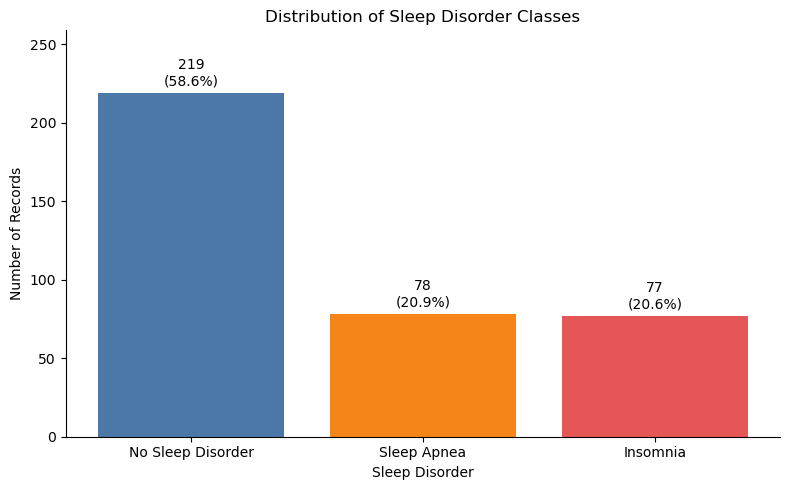

In [9]:
# Count the number of records in each target class
target_counts = df["Sleep Disorder"].value_counts()

# Calculate the percentage of each class
target_percentages = (
    target_counts / target_counts.sum() * 100
)

# Create the target distribution chart
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    target_counts.index,
    target_counts.values,
    color=["#4C78A8", "#F58518", "#E45756"]
)

# Display the count and percentage above each bar
for bar, percentage in zip(bars, target_percentages):
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 3,
        f"{int(height)}\n({percentage:.1f}%)",
        ha="center",
        va="bottom"
    )

ax.set_title("Distribution of Sleep Disorder Classes")
ax.set_xlabel("Sleep Disorder")
ax.set_ylabel("Number of Records")
ax.set_ylim(0, target_counts.max() + 40)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

The largest group is No Sleep Disorder, with 219 records or 58.6% of the dataset. Sleep Apnea has 78 records, while Insomnia has 77.

The classes are not evenly balanced because No Sleep Disorder has almost three times as many records as each disorder class. A model could appear accurate by favouring the largest class. Therefore, the train-test split should keep the same class proportions, and Macro F1 should be used together with accuracy when comparing the models.


### 2.3.1.2 Distribution of Features

The distributions of the numerical and categorical features are examined to understand their ranges, common values and possible data-quality issues.

### Numerical Feature Distribution

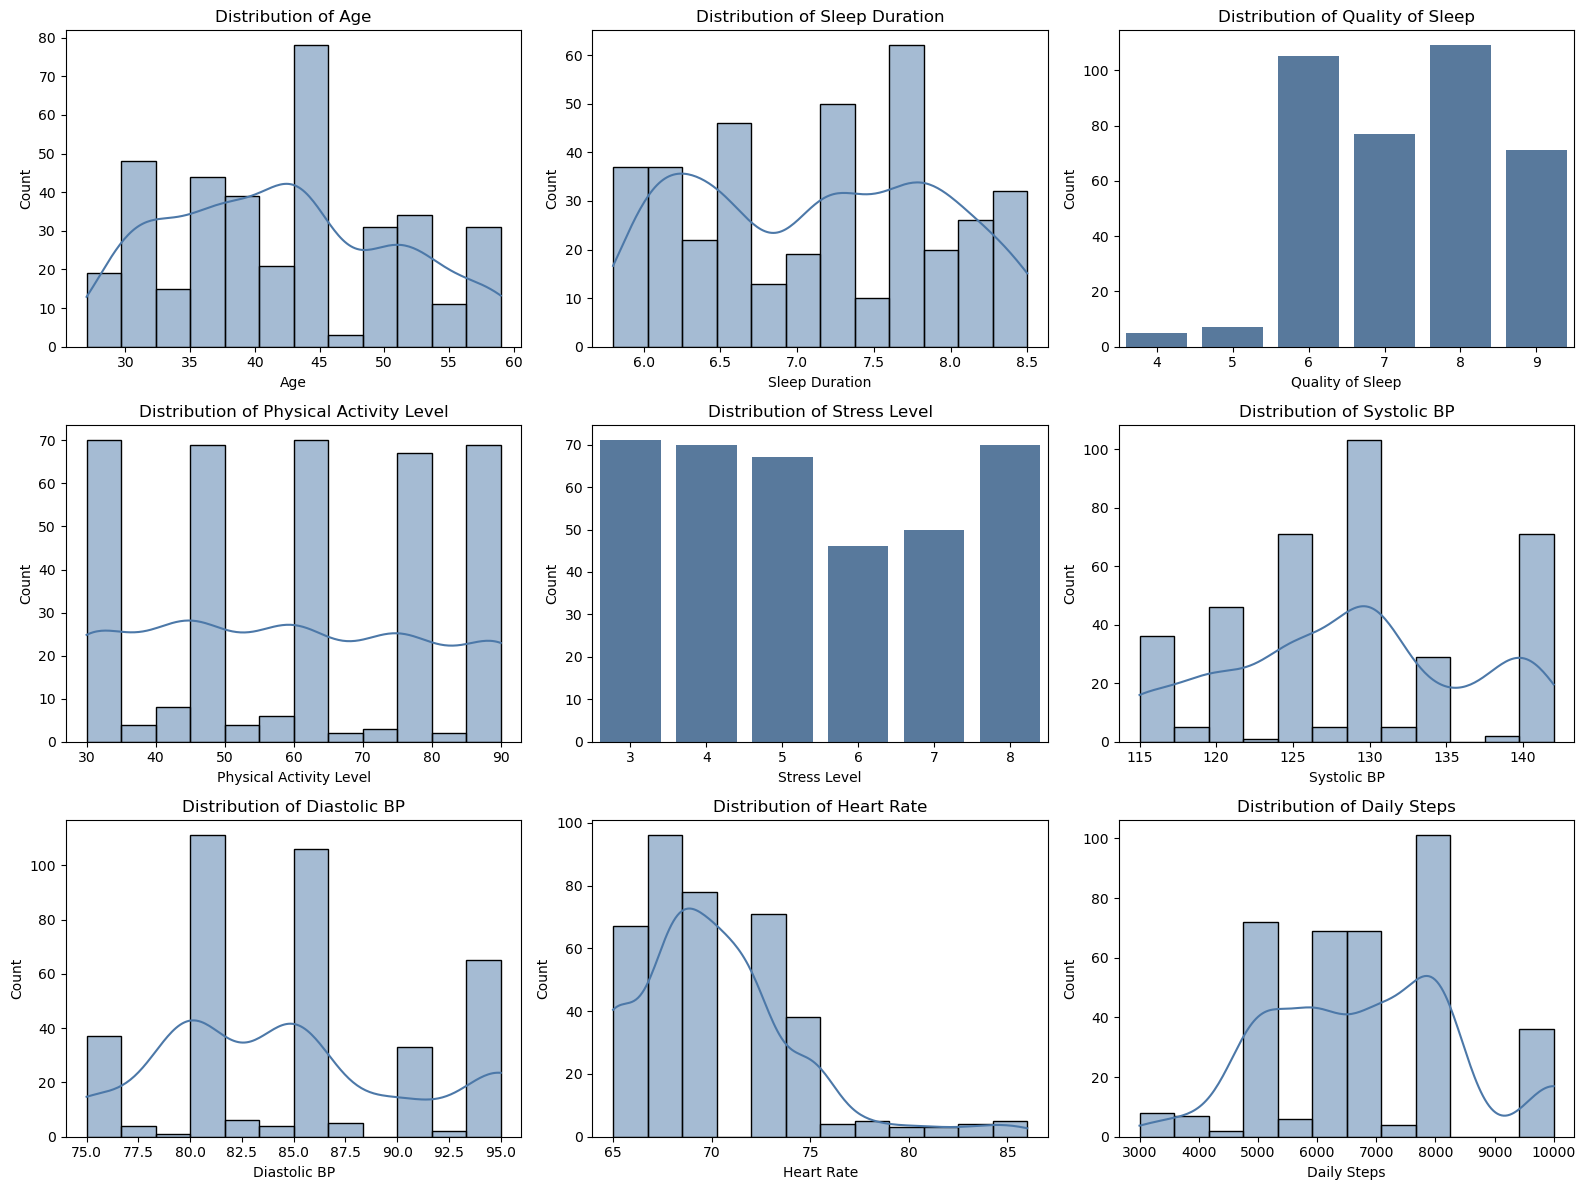

In [10]:
# Numerical features used for distribution analysis
numerical_features = [
    "Age",
    "Sleep Duration",
    "Quality of Sleep",
    "Physical Activity Level",
    "Stress Level",
    "Systolic BP",
    "Diastolic BP",
    "Heart Rate",
    "Daily Steps"
]

# These features contain fixed rating values, so count plots are clearer
discrete_features = [
    "Quality of Sleep",
    "Stress Level"
]

# Create a 3-by-3 layout
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for feature, ax in zip(numerical_features, axes):

    if feature in discrete_features:
        # Use a count plot for rating-based features
        feature_order = sorted(df[feature].unique())

        sns.countplot(
            data=df,
            x=feature,
            order=feature_order,
            color="#4C78A8",
            ax=ax
        )

    else:
        # Use a histogram for continuous numerical features
        sns.histplot(
            data=df,
            x=feature,
            bins=12,
            kde=True,
            color="#4C78A8",
            ax=ax
        )

    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

The numerical features have different ranges and distributions. Age ranges from 27 to 59, while sleep duration ranges from 5.8 to 8.5 hours. Most quality-of-sleep ratings are between 6 and 9.

Physical activity and daily steps are spread across a wide range, showing that the dataset contains people with different activity levels. Most heart-rate values are around 65 to 75, although a small number of higher readings can also be seen.

Since the numerical features use different scales, scaling may be useful for models such as Logistic Regression. Possible unusual values will be examined using box plots before deciding whether any action is needed.


### Gender and BMI Distribution

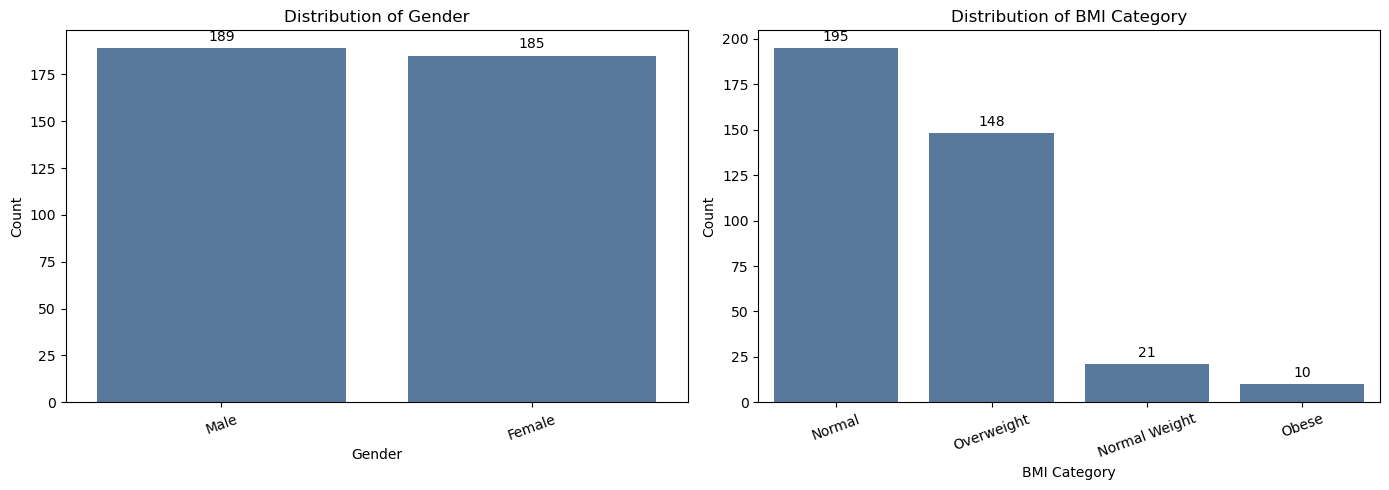

In [11]:
# Categorical features to display side by side
categorical_features = [
    "Gender",
    "BMI Category"
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for feature, ax in zip(categorical_features, axes):

    category_order = df[feature].value_counts().index

    sns.countplot(
        data=df,
        x=feature,
        order=category_order,
        color="#4C78A8",
        ax=ax
    )

    # Add the count above each bar
    ax.bar_label(ax.containers[0], padding=3)

    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

### Occupation Distribution

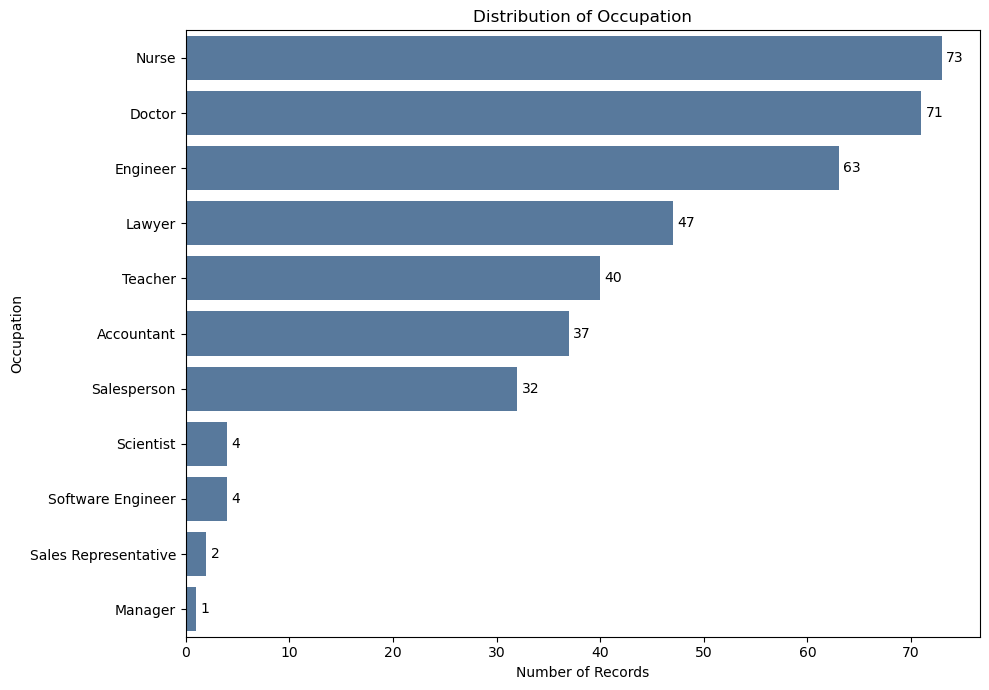

In [12]:
# Arrange occupations from the most common to the least common
occupation_order = df["Occupation"].value_counts().index

plt.figure(figsize=(10, 7))

ax = sns.countplot(
    data=df,
    y="Occupation",
    order=occupation_order,
    color="#4C78A8"
)

# Add the count beside each bar
ax.bar_label(ax.containers[0], padding=3)

ax.set_title("Distribution of Occupation")
ax.set_xlabel("Number of Records")
ax.set_ylabel("Occupation")

plt.tight_layout()
plt.show()

The gender distribution is almost balanced, with 189 males and 185 females.

For BMI category, `Normal` is the largest group, followed by `Overweight`. The dataset also contains both `Normal` and `Normal Weight`, even though they appear to represent the same category. These two labels should be combined during data cleaning. The `Obese` group contains only 10 records, so the model will have less data to learn from for this category.

The occupation distribution is uneven. Nurse, Doctor and Engineer are the most common occupations, while categories such as Manager, Sales Representative, Scientist and Software Engineer have very few records. Occupation will need to be encoded before modelling, but predictions involving rare occupations may be less reliable because there are fewer examples.


### 2.3.2 Understanding Relationships Between Variables

This section examines the relationships between the input features and the target. It helps identify useful patterns and features that may provide similar information.

### Correlation Heatmap

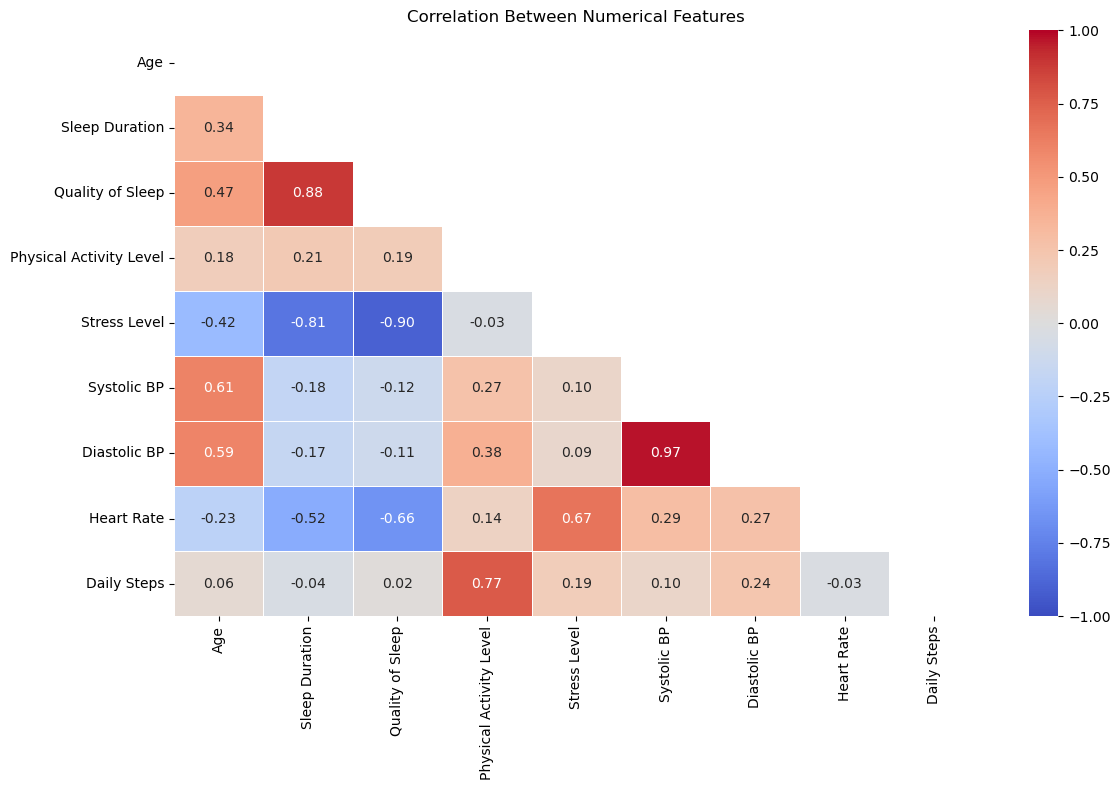

In [13]:
# Numerical features used for correlation analysis
correlation_features = [
    "Age",
    "Sleep Duration",
    "Quality of Sleep",
    "Physical Activity Level",
    "Stress Level",
    "Systolic BP",
    "Diastolic BP",
    "Heart Rate",
    "Daily Steps"
]

# Calculate the correlations
correlation_matrix = df[correlation_features].corr()

# Hide the repeated upper half of the heatmap
mask = np.triu(
    np.ones_like(correlation_matrix, dtype=bool)
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Correlation Between Numerical Features")
plt.tight_layout()
plt.show()

The heatmap shows several strong relationships between the numerical features. Quality of sleep has a strong positive relationship with sleep duration, with a correlation of 0.88. This means longer sleep is generally linked to better sleep quality in this dataset.

Stress level has a strong negative relationship with quality of sleep (-0.90) and sleep duration (-0.81). Higher stress is generally linked to shorter sleep and lower sleep quality.

Systolic and diastolic blood pressure have a very strong correlation of 0.97. Physical activity and daily steps are also strongly related, with a correlation of 0.77. These pairs may provide similar information to the model.

These relationships will be considered during feature selection. However, correlation does not prove that one feature directly causes another.


### Numerical Features compared with the Target

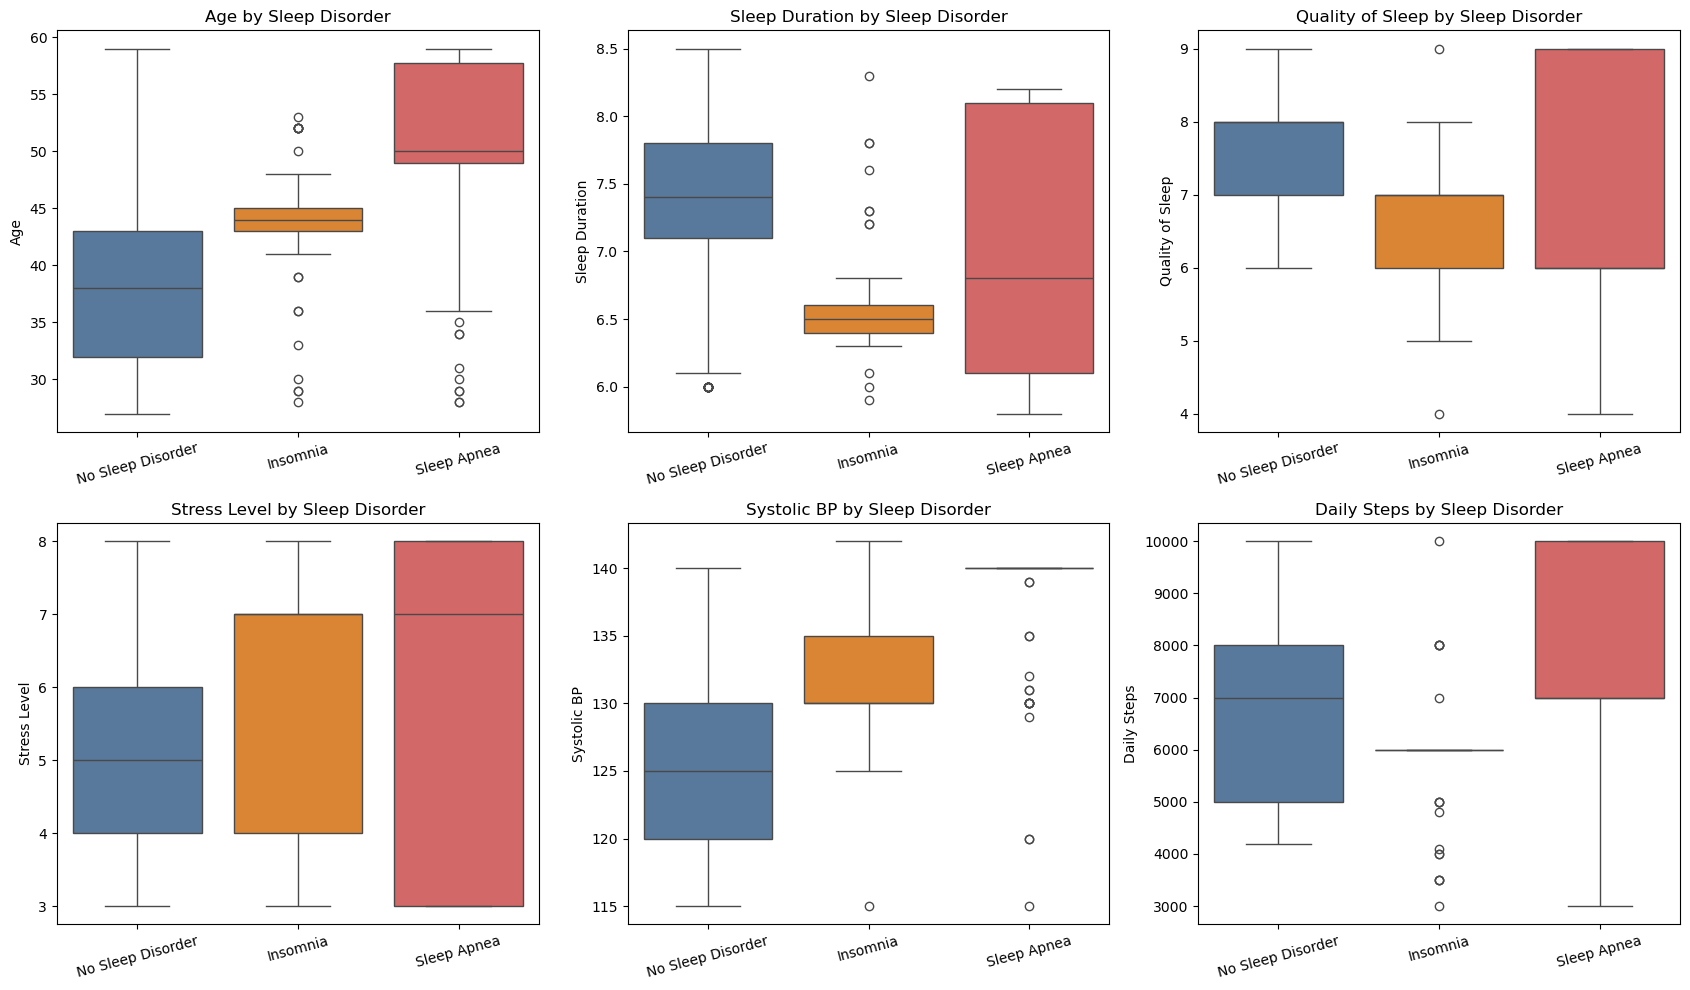

In [14]:
# Key numerical features selected from the earlier analysis
key_numerical_features = [
    "Age",
    "Sleep Duration",
    "Quality of Sleep",
    "Stress Level",
    "Systolic BP",
    "Daily Steps"
]

# Keep the same class order across all graphs
target_order = [
    "No Sleep Disorder",
    "Insomnia",
    "Sleep Apnea"
]

target_colours = [
    "#4C78A8",
    "#E45756",
    "#F58518"
]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

for feature, ax in zip(key_numerical_features, axes):

    sns.boxplot(
        data=df,
        x="Sleep Disorder",
        y=feature,
        order=target_order,
        hue="Sleep Disorder",
        palette=target_colours,
        legend=False,
        ax=ax
    )

    ax.set_title(f"{feature} by Sleep Disorder")
    ax.set_xlabel("")
    ax.set_ylabel(feature)
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

The box plots show noticeable differences between the sleep-disorder groups.

People with Insomnia generally have shorter sleep duration and lower sleep quality. Their stress levels are also generally higher than those without a sleep disorder.

People with Sleep Apnea are generally older and have higher systolic blood pressure. Their daily-step values are also higher in this dataset, although the values are spread across a wide range.

The groups still overlap in several features. This means one feature alone may not be enough to predict a sleep disorder, and the model will need to consider several features together. The points outside some box plots should be investigated before deciding whether they are actual errors or valid observations.


### BMI category compared with the target

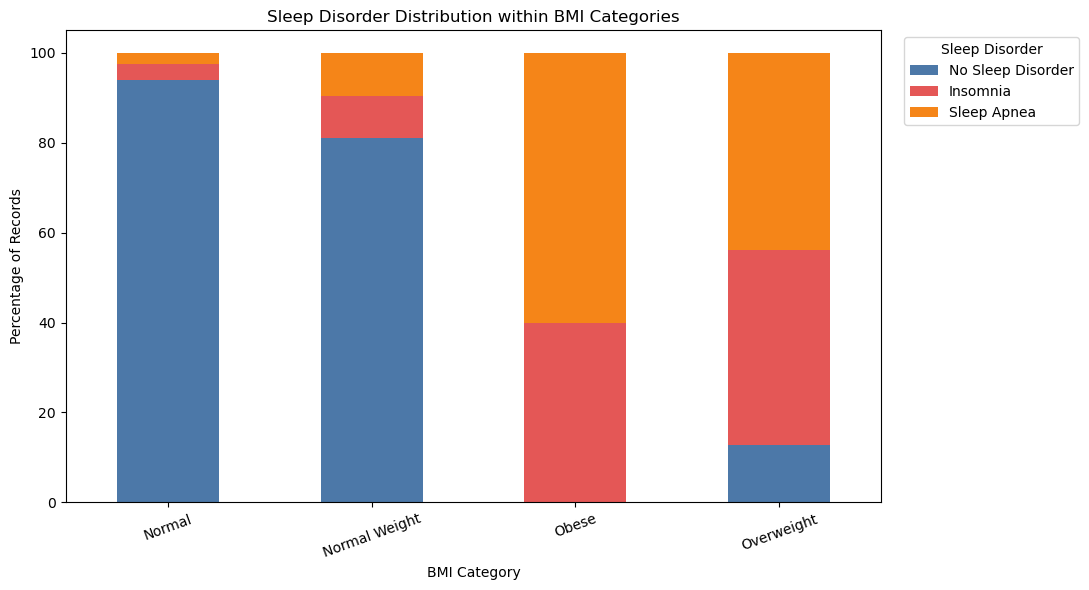

In [15]:
# Create a table showing BMI category against Sleep Disorder
bmi_target_counts = pd.crosstab(
    df["BMI Category"],
    df["Sleep Disorder"]
)

# Convert the counts into percentages within each BMI category
bmi_target_percentages = (
    bmi_target_counts
    .div(bmi_target_counts.sum(axis=1), axis=0)
    .mul(100)
)

# Keep the target classes in a consistent order
bmi_target_percentages = bmi_target_percentages[
    target_order
]

# Create a 100% stacked bar chart
ax = bmi_target_percentages.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
    color=target_colours
)

ax.set_title("Sleep Disorder Distribution within BMI Categories")
ax.set_xlabel("BMI Category")
ax.set_ylabel("Percentage of Records")
ax.legend(
    title="Sleep Disorder",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

BMI category shows a clear relationship with sleep disorder in this dataset. Most people in the `Normal` category have no sleep disorder. In comparison, most records in the `Overweight` category are linked to either Insomnia or Sleep Apnea.

All 10 records in the `Obese` category have a sleep disorder. However, this group is very small, so this result should be interpreted carefully.

The chart also shows that `Normal` and `Normal Weight` behave similarly. These labels appear to represent the same group and will be combined during data cleaning. BMI category may be an important predictor, but the model should not rely too heavily on a small number of categories or records.


# 3. Data Preparation

## 3.1 Data Cleaning

The earlier checks found no missing values or exact duplicate records, so no rows need to be filled or removed.

`Person ID` will be removed because it is only used to identify each person and does not provide useful information for prediction. The BMI labels `Normal` and `Normal Weight` will also be combined because they appear to describe the same category.

The original dataset will be kept unchanged, and the cleaning will be performed on a separate copy.


In [16]:
# Create a copy so the original dataset remains unchanged
df_clean = df.copy()

# Confirm the results found during Data Understanding
print(f"Original dataset shape: {df_clean.shape}")
print(f"Total missing values: {df_clean.isna().sum().sum()}")
print(f"Exact duplicate rows: {df_clean.duplicated().sum()}")

Original dataset shape: (374, 14)
Total missing values: 0
Exact duplicate rows: 0


In [17]:
# Display the BMI categories before standardisation
print("BMI categories before cleaning:")
display(df_clean["BMI Category"].value_counts())

BMI categories before cleaning:


BMI Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: count, dtype: int64

In [18]:
# Identify all text-based columns
text_columns = df_clean.select_dtypes(
    include="object"
).columns

# Remove accidental spaces before or after text values
df_clean[text_columns] = df_clean[text_columns].apply(
    lambda column: column.str.strip()
)

# Combine two labels that represent the same BMI category
df_clean["BMI Category"] = df_clean[
    "BMI Category"
].replace({
    "Normal Weight": "Normal"
})

In [19]:
# Remove Person ID because it is only an identifier
# and does not provide useful predictive information
df_clean = df_clean.drop(columns=["Person ID"])

In [20]:
# Check the cleaned dataset
print(f"Cleaned dataset shape: {df_clean.shape}")
print(f"Total missing values: {df_clean.isna().sum().sum()}")

print("\nBMI categories after cleaning:")
display(df_clean["BMI Category"].value_counts())

print("\nColumns available for modelling:")
display(pd.DataFrame({
    "Column": df_clean.columns
}))

# Display the first five cleaned records
display(df_clean.head())

Cleaned dataset shape: (374, 13)
Total missing values: 0

BMI categories after cleaning:


BMI Category
Normal        216
Overweight    148
Obese          10
Name: count, dtype: int64


Columns available for modelling:


,Column
0,Gender
1,Age
2,Occupation
3,Sleep Duration
4,Quality of Sleep
5,Physical Activity Level
6,Stress Level
7,BMI Category
8,Systolic BP
9,Diastolic BP


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Systolic BP,Diastolic BP,Heart Rate,Daily Steps,Sleep Disorder
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,126,83,77,4200,No Sleep Disorder
1,Male,28,Doctor,6.2,6,60,8,Normal,125,80,75,10000,No Sleep Disorder
2,Male,28,Doctor,6.2,6,60,8,Normal,125,80,75,10000,No Sleep Disorder
3,Male,28,Sales Representative,5.9,4,30,8,Obese,140,90,85,3000,Sleep Apnea
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140,90,85,3000,Sleep Apnea


In [21]:
# Check for repeated feature profiles after removing Person ID
repeated_profiles = df_clean.duplicated().sum()

print(
    "Repeated feature profiles after removing Person ID:",
    repeated_profiles
)

Repeated feature profiles after removing Person ID: 242


### Data Cleaning Results

The cleaned dataset contains 374 rows and 13 columns. `Person ID` was removed because it is only an identifier. The `Normal Weight` BMI label was combined with `Normal`, leaving three consistent BMI categories: Normal, Overweight and Obese.

No missing values were found, so no imputation was needed. No exact duplicate records were found before removing `Person ID`.

After removing the identifier, 242 rows had repeated feature combinations. These records were kept because they originally belonged to different Person IDs and may represent different people with the same recorded information. Removing them would reduce the dataset from 374 to 132 records and could remove useful information.

No unusual numerical values were removed because they are still within the recorded ranges of the dataset and may represent real health differences between individuals.


### 3.1.1. One-Hot Encoding

The categorical input features must be converted into numerical values before modelling. One-hot encoding is applied to `Gender`, `Occupation` and `BMI` Category. The first category from each feature is removed to avoid creating unnecessary duplicate information. The target variable `Sleep Disorder` is not encoded and remains unchanged.

In [22]:
# Apply one-hot encoding to the categorical input features
df_encoded = pd.get_dummies(
    df_clean,
    columns=['Gender', 'Occupation', 'BMI Category'],
    drop_first=True,
    dtype=int
)

# Check the encoded dataset
display(df_encoded.head())

print("Shape before encoding:", df_clean.shape)
print("Shape after encoding:", df_encoded.shape)

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Systolic BP,Diastolic BP,Heart Rate,Daily Steps,Sleep Disorder,...,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Obese,BMI Category_Overweight
0,27,6.1,6,42,6,126,83,77,4200,No Sleep Disorder,...,0,0,0,0,0,0,1,0,0,1
1,28,6.2,6,60,8,125,80,75,10000,No Sleep Disorder,...,0,0,0,0,0,0,0,0,0,0
2,28,6.2,6,60,8,125,80,75,10000,No Sleep Disorder,...,0,0,0,0,0,0,0,0,0,0
3,28,5.9,4,30,8,140,90,85,3000,Sleep Apnea,...,0,0,0,1,0,0,0,0,1,0
4,28,5.9,4,30,8,140,90,85,3000,Sleep Apnea,...,0,0,0,1,0,0,0,0,1,0


Shape before encoding: (374, 13)
Shape after encoding: (374, 23)


### 3.2 Train-Test Split

The cleaned dataset is split into training and testing sets using a 60:40 ratio. The training set is used to train the models, while the test set is kept separate to evaluate how well the models perform on unseen data.

Stratification is used because the target classes are unevenly distributed. This keeps approximately the same class proportions in both sets.


In [23]:
# Separate the input features and target variable
X = df_encoded.drop(columns=['Sleep Disorder'])
y = df_encoded['Sleep Disorder']

# Split the dataset into 60% training and 40% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

# Check the size of each set
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (224, 22)
X_test shape: (150, 22)
y_train shape: (224,)
y_test shape: (150,)


In [24]:
# Compare the target distribution in both sets
class_order = y.value_counts().index

split_summary = pd.DataFrame({
    'Full Dataset': y.value_counts().reindex(class_order),
    'Training Set': y_train.value_counts().reindex(class_order),
    'Test Set': y_test.value_counts().reindex(class_order),
    'Training (%)': (
        y_train.value_counts(normalize=True)
        .reindex(class_order)
        .mul(100)
        .round(2)
    ),
    'Test (%)': (
        y_test.value_counts(normalize=True)
        .reindex(class_order)
        .mul(100)
        .round(2)
    )
})

display(split_summary)

,Full Dataset,Training Set,Test Set,Training (%),Test (%)
Sleep Disorder,,,,,
No Sleep Disorder,219,131,88,58.48,58.67
Sleep Apnea,78,47,31,20.98,20.67
Insomnia,77,46,31,20.54,20.67


### Split Summary

The split produced 224 training records and 150 testing records. All three sleep-disorder classes are represented in both sets, with similar class proportions.

A random state of 42 was used so that the same split can be reproduced. The test data will not be used during preprocessing, model training or hyperparameter tuning. It will only be used to evaluate the completed models.


# 4. Modelling

### 4.1 Model Selection

Four classification models were selected for this project: Decision Tree, Random Forest, Logistic Regression and Gradient Boosting. These models use different learning methods, which allows their performance to be compared fairly.

The Decision Tree is used as the baseline model. It is simple to understand and provides a useful starting result without any tuning.

Random Forest combines predictions from multiple decision trees. This usually makes it more stable and less likely to overfit than a single tree.

Logistic Regression is included as a simpler linear model. It provides a useful comparison against the tree-based models, although it may not capture more complex relationships as effectively.

Gradient Boosting builds trees one after another, with each new tree trying to correct earlier mistakes. It can produce strong results, but it is usually more difficult to explain than a single Decision Tree.

The models will first be trained using their initial settings. Their results will then be compared using Macro F1 as the main metric because all three sleep-disorder classes are important. Accuracy, class-level results, interpretability and deployment needs will also be considered when selecting the final model.


### 4.2 Train Models

All four models are trained using the same training data to ensure a fair comparison. The Decision Tree is treated as the baseline model, while the other three models provide alternative approaches.

No hyperparameter tuning is carried out at this stage. The initial results will be used to identify which model should be improved later.


In [25]:
# Create the models using their initial settings
models = {
    'Decision Tree (Baseline)': DecisionTreeClassifier(
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        random_state=42
    ),

    'Logistic Regression': Pipeline(
        steps=[
            ('scaler', StandardScaler()),
            (
                'classifier',
                LogisticRegression(
                    max_iter=1000,
                    random_state=42
                )
            )
        ]
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42
    )
}

In [26]:
# Store the fitted models and their training results
trained_models = {}
training_results = []

for model_name, model in models.items():

    # Train the model
    model.fit(X_train, y_train)

    # Store the fitted model for later evaluation
    trained_models[model_name] = model

    # Make predictions on the training set
    y_train_pred = model.predict(X_train)

    # Record the training results
    training_results.append({
        'Model': model_name,
        'Training Accuracy': accuracy_score(
            y_train,
            y_train_pred
        ),
        'Training Macro F1': f1_score(
            y_train,
            y_train_pred,
            average='macro'
        )
    })

    print(f'{model_name} trained successfully.')

Decision Tree (Baseline) trained successfully.
Random Forest trained successfully.
Logistic Regression trained successfully.
Gradient Boosting trained successfully.


In [27]:
# Convert the training results into a table
training_results_df = pd.DataFrame(training_results)

display(training_results_df.round(4))

,Model,Training Accuracy,Training Macro F1
0,Decision Tree (Baseline),0.9375,0.9299
1,Random Forest,0.9375,0.9293
2,Logistic Regression,0.9196,0.9078
3,Gradient Boosting,0.9375,0.9299


### Training Summary

All four models were trained successfully using the same training set. The training results show that the tree-based models fitted the training data slightly better than Logistic Regression.

However, a high training score does not necessarily mean that a model will perform well on unseen data. The models must still be evaluated using the test set before the final model is selected.


# 5. Model Evaluation

## 5.1 Evaluation Metrics

The models are evaluated using Accuracy and Macro F1.

Accuracy shows the percentage of correct predictions. However, the target classes are uneven, so accuracy alone may be misleading.

Macro F1 is used as the main metric because it gives equal importance to all three classes. This helps check whether the model can identify Insomnia and Sleep Apnea, instead of only performing well on the largest class.

In [28]:
# Store test predictions and results
model_predictions = {}
evaluation_results = []

for model_name, model in trained_models.items():

    # Predict using the test set
    y_test_pred = model.predict(X_test)
    model_predictions[model_name] = y_test_pred

    # Record the test results
    evaluation_results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_test_pred),
        'Macro F1': f1_score(
            y_test,
            y_test_pred,
            average='macro'
        )
    })

# Create the comparison table
evaluation_results_df = pd.DataFrame(evaluation_results)

# Get the Decision Tree baseline score
baseline_f1 = evaluation_results_df.loc[
    evaluation_results_df['Model'] == 'Decision Tree (Baseline)',
    'Macro F1'
].iloc[0]

# Compare each model with the baseline
evaluation_results_df['F1 Change vs Baseline'] = (
    evaluation_results_df['Macro F1'] - baseline_f1
)

# Rank the models using Macro F1
evaluation_results_df['Macro F1 Rank'] = (
    evaluation_results_df['Macro F1']
    .rank(ascending=False, method='min')
    .astype(int)
)

display(evaluation_results_df.round(4))

,Model,Accuracy,Macro F1,F1 Change vs Baseline,Macro F1 Rank
0,Decision Tree (Baseline),0.8933,0.8602,0.0000,4
1,Random Forest,0.9200,0.8948,0.0345,1
2,Logistic Regression,0.9067,0.8859,0.0256,2
3,Gradient Boosting,0.8933,0.8654,0.0052,3


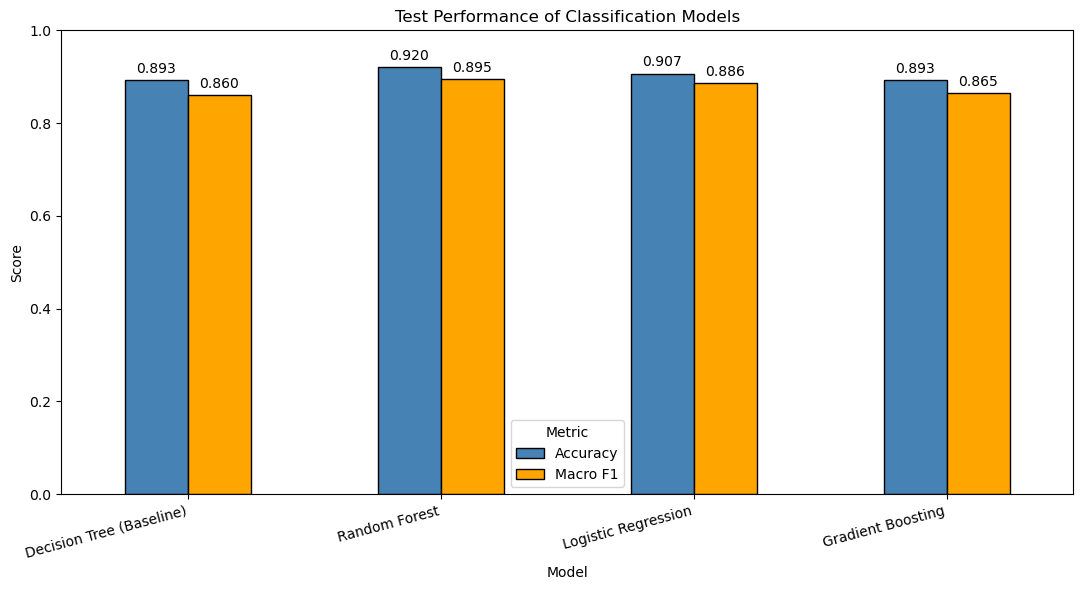

In [29]:
# Prepare the results for plotting
comparison_plot = evaluation_results_df.set_index('Model')[
    ['Accuracy', 'Macro F1']
]

ax = comparison_plot.plot(
    kind='bar',
    figsize=(11, 6),
    color=['steelblue', 'orange'],
    edgecolor='black'
)

ax.set_title('Test Performance of Classification Models')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(title='Metric')

plt.xticks(rotation=15, ha='right')

# Show the score above each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',
        padding=3
    )

plt.tight_layout()
plt.show()

In [30]:
class_names = [
    'No Sleep Disorder',
    'Insomnia',
    'Sleep Apnea'
]

class_f1_results = []

for model_name, y_test_pred in model_predictions.items():

    report = classification_report(
        y_test,
        y_test_pred,
        output_dict=True,
        zero_division=0
    )

    class_f1_results.append({
        'Model': model_name,
        'No Sleep Disorder F1': report[
            'No Sleep Disorder'
        ]['f1-score'],
        'Insomnia F1': report[
            'Insomnia'
        ]['f1-score'],
        'Sleep Apnea F1': report[
            'Sleep Apnea'
        ]['f1-score']
    })

class_f1_results_df = pd.DataFrame(class_f1_results)

display(class_f1_results_df.round(4))

,Model,No Sleep Disorder F1,Insomnia F1,Sleep Apnea F1
0,Decision Tree (Baseline),0.9486,0.8125,0.8197
1,Random Forest,0.9605,0.8667,0.8571
2,Logistic Regression,0.9425,0.8667,0.8485
3,Gradient Boosting,0.9379,0.8276,0.8308


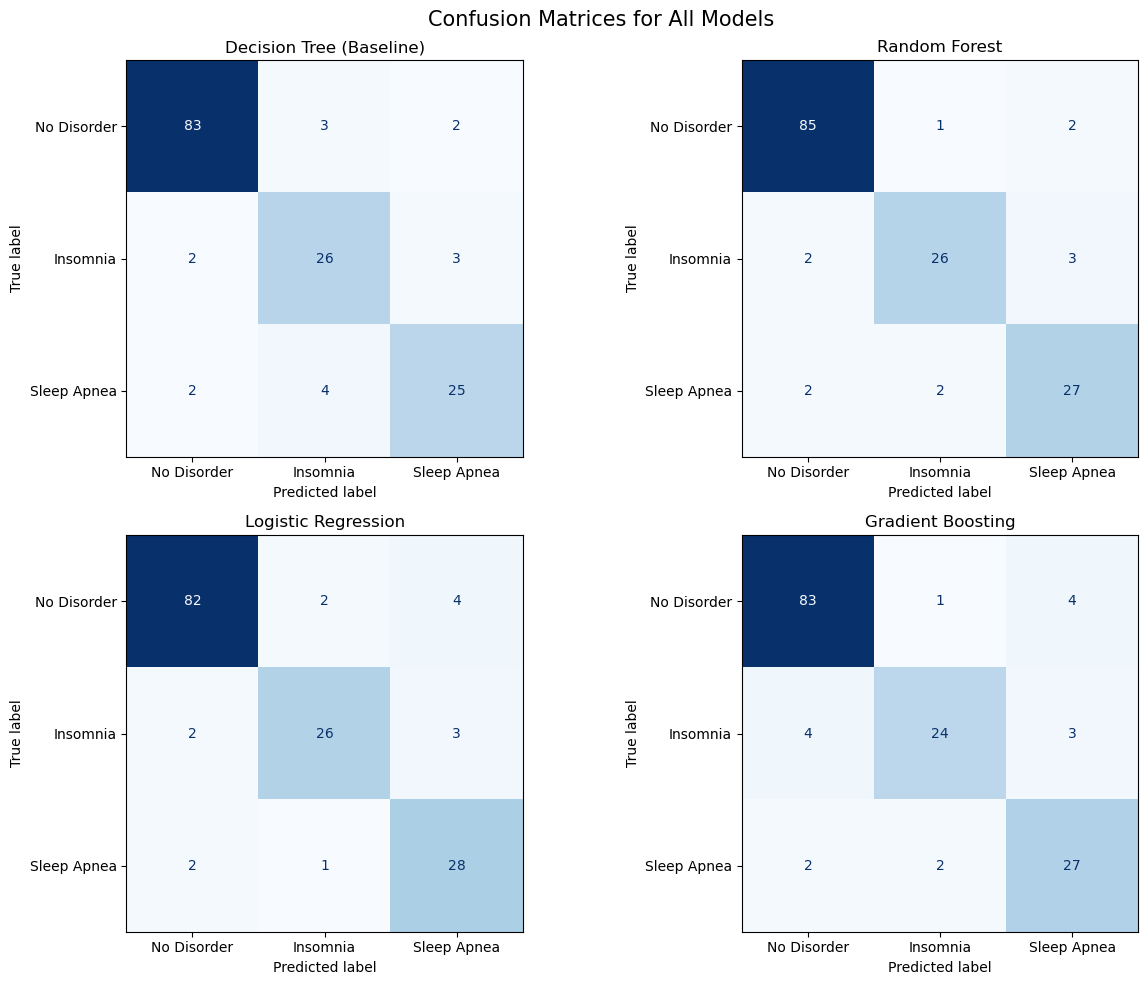

In [31]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 10)
)

axes = axes.flatten()

display_labels = [
    'No Disorder',
    'Insomnia',
    'Sleep Apnea'
]

for ax, (model_name, y_test_pred) in zip(
    axes,
    model_predictions.items()
):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_test_pred,
        labels=class_names,
        display_labels=display_labels,
        cmap='Blues',
        colorbar=False,
        ax=ax
    )

    ax.set_title(model_name)

plt.suptitle(
    'Confusion Matrices for All Models',
    fontsize=15
)

plt.tight_layout()
plt.show()

### Model Evaluation Findings

Random Forest produced the best initial result, with an accuracy of 92.00% and a Macro F1 score of 0.8948. Its Macro F1 was 0.0345 higher than the Decision Tree baseline.

Random Forest also performed well across all three classes. It correctly predicted 85 out of 88 people with no sleep disorder, 26 out of 31 people with Insomnia, and 27 out of 31 people with Sleep Apnea.

Logistic Regression was the second-best model. Its results were close to Random Forest, and it is easier to explain. However, Random Forest gave the best overall balance across the three classes.

Gradient Boosting only improved slightly over the baseline. Based on these initial results, Random Forest will be selected for further tuning. It is harder to explain than a single Decision Tree, but it is still practical for the planned application and provides better predictions across the target classes.


### Five-Fold Cross-Validation

Five-fold cross-validation is used to compare the four models. The training data is divided into five parts. Each model is trained using four parts and validated using the remaining part. This is repeated until every part has been used for validation.

Stratification is used to keep a similar number of each sleep-disorder class in every fold. Macro F1 is the main metric because all three classes are important.


In [32]:
# Set up stratified five-fold cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for model_name, model in models.items():

    # Run cross-validation using only the training set
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            'accuracy': 'accuracy',
            'macro_f1': 'f1_macro'
        },
        return_train_score=True,
        n_jobs=-1
    )

    mean_train_f1 = scores['train_macro_f1'].mean()
    mean_validation_f1 = scores['test_macro_f1'].mean()

    cv_results.append({
        'Model': model_name,
        'Mean CV Accuracy': scores[
            'test_accuracy'
        ].mean(),
        'Accuracy SD': scores[
            'test_accuracy'
        ].std(),
        'Mean CV Macro F1': mean_validation_f1,
        'Macro F1 SD': scores[
            'test_macro_f1'
        ].std(),
        'Train-CV F1 Gap': (
            mean_train_f1 - mean_validation_f1
        )
    })

# Create and rank the comparison table
cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by='Mean CV Macro F1',
    ascending=False
).reset_index(drop=True)

cv_results_df['Rank'] = (
    cv_results_df.index + 1
)

display(cv_results_df.round(4))

,Model,Mean CV Accuracy,Accuracy SD,Mean CV Macro F1,Macro F1 SD,Train-CV F1 Gap,Rank
0,Logistic Regression,0.9014,0.0601,0.8820,0.0747,0.0280,1
1,Gradient Boosting,0.8924,0.0707,0.8692,0.0885,0.0628,2
2,Random Forest,0.8835,0.0719,0.8608,0.0895,0.0713,3
3,Decision Tree (Baseline),0.8388,0.0828,0.8173,0.1022,0.1154,4


### Cross-Validation Findings

Logistic Regression produced the highest average Macro F1 score of 0.8820. It also had the smallest difference between its training and validation scores, showing that its results were more consistent.

The Decision Tree had the lowest validation score and the largest gap between its training and validation results. This suggests that the baseline model may be overfitting.

Based on the cross-validation results, Logistic Regression is selected for further model development and hyperparameter tuning.


## 6. Iterative model development


### Logistic Regression Development

Logistic Regression was selected because it had the highest average Macro F1 score during five-fold cross-validation.

The model will be improved in two steps. First, highly correlated features will be removed to reduce repeated information. After that, hyperparameter tuning will be carried out using Randomized Search.


### 6.1 Feature Selection

In [33]:
# Features that contain similar information
correlation_pairs = [
    ('Diastolic BP', 'Systolic BP'),
    ('Stress Level', 'Quality of Sleep'),
    ('Daily Steps', 'Physical Activity Level')
]

correlation_results = []

for removed_feature, kept_feature in correlation_pairs:
    correlation_results.append({
        'Feature to Remove': removed_feature,
        'Similar Feature Kept': kept_feature,
        'Absolute Correlation': abs(
            X_train[removed_feature].corr(
                X_train[kept_feature]
            )
        )
    })

correlation_results_df = pd.DataFrame(
    correlation_results
)

display(correlation_results_df.round(3))

,Feature to Remove,Similar Feature Kept,Absolute Correlation
0,Diastolic BP,Systolic BP,0.974
1,Stress Level,Quality of Sleep,0.886
2,Daily Steps,Physical Activity Level,0.806


In [34]:
# Remove one feature from each highly correlated pair
features_to_remove = [
    'Diastolic BP',
    'Stress Level',
    'Daily Steps'
]

selected_features = [
    feature
    for feature in X_train.columns
    if feature not in features_to_remove
]

X_train_selected = X_train[selected_features].copy()
X_test_selected = X_test[selected_features].copy()

print("Original number of features:", X_train.shape[1])
print("Selected number of features:", X_train_selected.shape[1])
print("Removed features:", features_to_remove)

Original number of features: 22
Selected number of features: 19
Removed features: ['Diastolic BP', 'Stress Level', 'Daily Steps']


In [35]:
# Logistic Regression pipeline for comparison
logistic_development_model = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        (
            'classifier',
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

feature_selection_results = []

feature_sets = {
    'All Features': X_train,
    'Selected Features': X_train_selected
}

for feature_set_name, X_feature_set in feature_sets.items():

    scores = cross_validate(
        logistic_development_model,
        X_feature_set,
        y_train,
        cv=cv,
        scoring='f1_macro',
        return_train_score=True,
        n_jobs=-1
    )

    feature_selection_results.append({
        'Feature Set': feature_set_name,
        'Number of Features': X_feature_set.shape[1],
        'Mean CV Macro F1': scores[
            'test_score'
        ].mean(),
        'Macro F1 SD': scores[
            'test_score'
        ].std(),
        'Mean Training Macro F1': scores[
            'train_score'
        ].mean()
    })

feature_selection_results_df = pd.DataFrame(
    feature_selection_results
)

display(feature_selection_results_df.round(4))

,Feature Set,Number of Features,Mean CV Macro F1,Macro F1 SD,Mean Training Macro F1
0,All Features,22,0.882,0.0747,0.9099
1,Selected Features,19,0.882,0.0747,0.9099


### Feature Selection Findings

Three features were removed because they were highly correlated with other features. The number of inputs was reduced from 22 to 19.

The average Macro F1 remained at 0.8820 after the features were removed. This means the model became simpler without losing cross-validation performance.

Sleep Duration and Quality of Sleep were both kept because they measure different things. Sleep Duration measures the number of hours slept, while Quality of Sleep measures how well the person slept.


### 6.2 Hyperparameter Tuning

In [36]:
# Pipeline for the developed Logistic Regression model
logistic_tuning_pipeline = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        (
            'classifier',
            LogisticRegression(
                solver='lbfgs',
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Hyperparameters to test
logistic_param_dist = {
    'classifier__C': [
        0.01,
        0.1,
        1,
        10,
        100
    ],
    'classifier__class_weight': [
        None,
        'balanced'
    ]
}

In [37]:
## run the RandomizedSearchCV to find the best hyperparameters
logistic_random_search = RandomizedSearchCV(
    estimator=logistic_tuning_pipeline,
    param_distributions=logistic_param_dist,
    n_iter=8,
    scoring='f1_macro',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    return_train_score=True,
    refit=True
)

# Use only the selected training features
logistic_random_search.fit(
    X_train_selected,
    y_train
)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__C': [0.01, 0.1, ...], 'classifier__class_weight': [None, 'balanced']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",8
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if

In [38]:
## Display the best hyperparameters and the corresponding mean CV Macro F1 score
print(
    "Best parameters:",
    logistic_random_search.best_params_
)

print(
    "Best mean CV Macro F1:",
    round(logistic_random_search.best_score_, 4)
)

Best parameters: {'classifier__class_weight': None, 'classifier__C': 1}
Best mean CV Macro F1: 0.882


In [39]:
## Show the results of the hyperparameter tuning
tuning_results = pd.DataFrame(
    logistic_random_search.cv_results_
)

tuning_log = tuning_results[[
    'rank_test_score',
    'param_classifier__C',
    'param_classifier__class_weight',
    'mean_train_score',
    'mean_test_score',
    'std_test_score'
]].copy()

tuning_log.columns = [
    'Rank',
    'C',
    'Class Weight',
    'Mean Training Macro F1',
    'Mean CV Macro F1',
    'CV Macro F1 SD'
]

tuning_log['Class Weight'] = (
    tuning_log['Class Weight'].fillna('None')
)

tuning_log = tuning_log.sort_values(
    by='Rank'
)

display(tuning_log.round(4))

,Rank,C,Class Weight,Mean Training Macro F1,Mean CV Macro F1,CV Macro F1 SD
7,1,1.00,None,0.9099,0.8820,0.0747
2,2,1.00,balanced,0.9034,0.8693,0.0672
1,3,0.01,balanced,0.8786,0.8622,0.0565
5,4,0.10,None,0.8898,0.8616,0.0665
4,5,10.00,balanced,0.9081,0.8550,0.0876
0,6,100.00,None,0.9177,0.8542,0.0714
6,7,100.00,balanced,0.9119,0.8464,0.0817
3,8,0.01,None,0.8589,0.8414,0.0658


### Hyperparameter Tuning Findings

Randomized Search tested different values for `C` and `class_weight`. The best settings were `C = 1` and no class weighting.

The tuned settings did not increase the cross-validation score above 0.8820. This shows that the original Logistic Regression settings were already suitable for this dataset. The main improvement came from removing repeated information rather than changing the model settings.


In [41]:
# Store the developed model
final_logistic_model = (
    logistic_random_search.best_estimator_
)

# Predict using the selected test features
y_test_pred_final = final_logistic_model.predict(
    X_test_selected
)

In [42]:
# Predictions from the earlier models
y_test_pred_tree = trained_models[
    'Decision Tree (Baseline)'
].predict(X_test)

y_test_pred_original_logistic = trained_models[
    'Logistic Regression'
].predict(X_test)

development_comparison = pd.DataFrame({
    'Model': [
        'Decision Tree Baseline',
        'Original Logistic Regression',
        'Developed Logistic Regression'
    ],
    'Number of Features': [
        X_test.shape[1],
        X_test.shape[1],
        X_test_selected.shape[1]
    ],
    'Accuracy': [
        accuracy_score(
            y_test,
            y_test_pred_tree
        ),
        accuracy_score(
            y_test,
            y_test_pred_original_logistic
        ),
        accuracy_score(
            y_test,
            y_test_pred_final
        )
    ],
    'Macro F1': [
        f1_score(
            y_test,
            y_test_pred_tree,
            average='macro'
        ),
        f1_score(
            y_test,
            y_test_pred_original_logistic,
            average='macro'
        ),
        f1_score(
            y_test,
            y_test_pred_final,
            average='macro'
        )
    ]
})

baseline_f1 = development_comparison.loc[
    development_comparison[
        'Model'
    ] == 'Decision Tree Baseline',
    'Macro F1'
].iloc[0]

development_comparison[
    'F1 Change vs Baseline'
] = (
    development_comparison['Macro F1']
    - baseline_f1
)

display(development_comparison.round(4))

,Model,Number of Features,Accuracy,Macro F1,F1 Change vs Baseline
0,Decision Tree Baseline,22,0.8933,0.8602,0.0000
1,Original Logistic Regression,22,0.9067,0.8859,0.0256
2,Developed Logistic Regression,19,0.9200,0.9034,0.0431


### Model Development Findings

The developed Logistic Regression achieved an accuracy of 92.00% and a Macro F1 score of 0.9034.

Its Macro F1 increased by 0.0175 compared with the original Logistic Regression and by 0.0431 compared with the Decision Tree baseline. It also uses three fewer features.

The developed Logistic Regression is selected as the final model because it gave better results, uses fewer inputs, and is easier to explain and deploy than the ensemble models.
